# Árvores de Decisão

**Instituto Federal de Educação, Ciência e Tecnologia de Goiás**

**Mestrado Profissional em Tecnologia, Gestão e Sustentabilidade**

**Métodos de Previsão**

**Prof. Dr. Raphael Gomes**

Este notebook contém todo o conteúdo da Aula 07 com exemplos práticos e exercícios adicionais.

## Configuração

Este projeto requer Python 3.7 ou superior:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Também requer o Scikit-Learn ≥ 1.0.1:

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Como fizemos nas aulas anteriores, vamos definir os tamanhos de fonte padrão para deixar as figuras mais bonitas:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Treinamento e visualização de uma árvore de decisão

Uma árvore de decisão usa uma estrutura de árvore para representar um número de possíveis *caminhos de decisão* (*decision paths*) e um resultado para cada caminho.

Se você já jogou o jogo [*Twenty Questions*](https://en.wikipedia.org/wiki/Twenty_Questions), então você está familiarizado com as árvores de decisão. Por exemplo:

* "Estou pensando em um animal".
* "Tem mais de cinco pernas?"
* "Não."
* "É delicioso?"
* "Não."
* "Aparece na parte de trás da moeda australiana de cinco centavos?"
* "Sim."
* “É uma [équidna](https://pt.wikipedia.org/wiki/Equidna-de-focinho-curto)?”
* "Sim!"

Isso corresponde ao caminho:

"Não mais que 5 pernas" $\rightarrow$ "Não é delicioso" $\rightarrow$ "Na moeda de 5 centavos" $\rightarrow$ "Echidna!"

em uma árvore de decisão idiossincrática (e não muito abrangente) "adivinhe o animal":

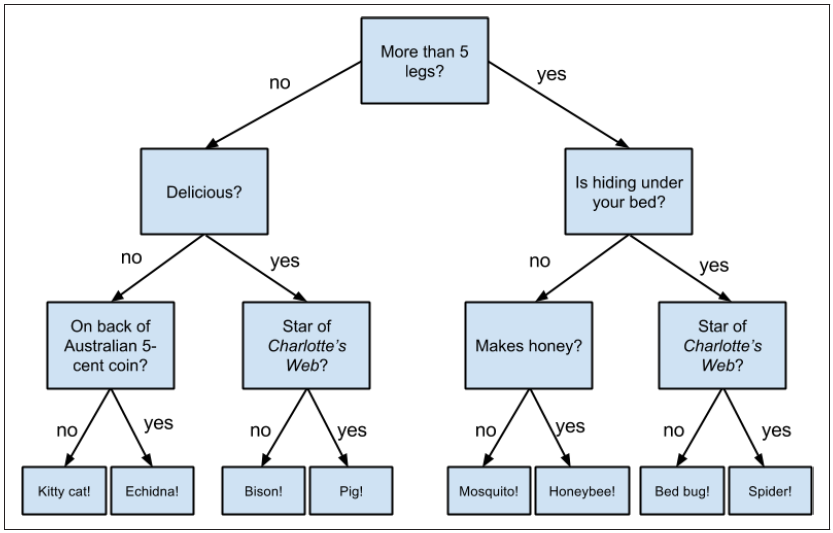

As árvores de decisão possuem muitos pontos positivos. Eles são muito fáceis de entender e interpretar, e o processo pelo qual elas alcançam uma previsão é completamente transparente. As árvores de decisão podem lidar facilmente com uma combinação de atributos numéricos (por exemplo, número de pernas) e categóricos (por exemplo, delicioso / não delicioso) e podem até classificar dados cujos atributos estão ausentes.

Ao mesmo tempo, encontrar uma árvore de decisão "ótima" para um conjunto de dados de treinamento é computacionalmente um problema muito difícil. (Vamos contornar isso tentando construir uma árvore que seja boa o suficiente em vez de uma ótima, embora para grandes conjuntos de dados isso ainda possa ser muito trabalhoso.) Mais importante, é muito fácil (e muito ruim) construir árvores de decisão que são sobreajustadas (*overfitted*) aos dados de treinamento, e que não generalizam bem para dados não vistos. Vamos procurar maneiras de resolver isso.

O **Decision Tree Classifier** é um modelo supervisionado que aprende regras de decisão hierárquicas a partir dos dados. É um dos modelos mais interpretáveis do aprendizado de máquina.

Neste exemplo, utilizamos o clássico dataset **Iris**, que contém medidas morfológicas de três espécies de flores (*Iris setosa*, *Iris versicolor* e *Iris virginica*). Para simplificar a visualização, usamos apenas duas *features*:

- `petal length (cm)` — comprimento da pétala
- `petal width (cm)` — largura da pétala

O parâmetro `max_depth=2` limita a profundidade da árvore, controlando a complexidade do modelo e evitando overfitting.

In [ ]:
# Importa o dataset Iris diretamente do scikit-learn
from sklearn.datasets import load_iris

# Importa o classificador de Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier


# Carrega o dataset Iris como DataFrame pandas (as_frame=True)
iris = load_iris(as_frame=True)

# Seleciona apenas as duas features de pétala como matriz NumPy
# Reduzir para 2 dimensões facilita a visualização futura da fronteira de decisão
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values

# Extrai os rótulos (classes): 0 = setosa, 1 = versicolor, 2 = virginica
y_iris = iris.target


# Instancia a Árvore de Decisão com profundidade máxima de 2 níveis
# - max_depth=2: limita a complexidade e reduz risco de overfitting
# - random_state=42: garante reprodutibilidade dos resultados
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)

# Treina o modelo com os dados de features (X) e rótulos (y)
tree_clf.fit(X_iris, y_iris)

Após o treinamento, é fundamental **visualizar a estrutura da árvore** para interpretar as regras de decisão aprendidas pelo modelo. A função `export_graphviz` do scikit-learn exporta a árvore treinada para o formato `.dot` — um formato de texto utilizado pela biblioteca **Graphviz** para renderizar grafos.

In [ ]:
# Importa a função que serializa a árvore treinada no formato DOT (Graphviz)
from sklearn.tree import export_graphviz


export_graphviz(
    tree_clf,                                          # Modelo de árvore já treinado
    out_file=str("iris_tree.dot"),                     # Caminho do arquivo de saída no formato DOT
    feature_names=["petal length (cm)", "petal width (cm)"],  # Nomes das features exibidos nos nós de divisão
    class_names=iris.target_names,                     # Nomes das classes exibidos nas folhas (setosa, versicolor, virginica)
    rounded=True,                                      # Arredonda os cantos dos nós para melhor estética
    filled=True                                        # Preenche os nós com cor proporcional à classe majoritária
)

Com o arquivo `.dot` gerado, utilizamos a biblioteca **Graphviz** (wrapper Python) para renderizar e exibir a árvore diretamente no Jupyter Notebook, sem precisar converter manualmente pelo terminal.

O método `Source.from_file()` lê o arquivo `.dot` e retorna um objeto `Source` que, ao ser avaliado como última expressão de uma célula, renderiza automaticamente a árvore como imagem SVG inline.

In [ ]:
# Importa a classe Source da biblioteca graphviz (wrapper Python para o Graphviz)
from graphviz import Source


# Lê o arquivo .dot gerado anteriormente e cria um objeto Source
# Quando executado como última expressão da célula, o Jupyter renderiza
# automaticamente a árvore como imagem SVG inline no notebook
Source.from_file("iris_tree.dot")

O Graphviz também fornece a ferramenta de linha de comando `dot` para converter arquivos `.dot` em diversos formatos. O comando a seguir converte o arquivo .dot em uma imagem PNG:

In [ ]:
!dot -Tpng {"iris_tree.dot"} -o {"iris_tree.png"}

## Fazendo Previsões

Um dos maiores diferenciais das Árvores de Decisão é sua **interpretabilidade visual**. Como cada divisão corresponde a um limiar (*threshold*) em uma única feature, as fronteiras de decisão são sempre **retas paralelas aos eixos**.

Nesta célula, fazemos duas coisas em paralelo:

1. **Plotamos a fronteira de decisão** do modelo `tree_clf` (`max_depth=2`), colorindo o espaço de entrada de acordo com a classe prevista
2. **Treinamos uma árvore mais profunda** (`max_depth=3`) exclusivamente para extrair os limiares dos níveis adicionais e desenhá-los como linhas de referência no gráfico

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Define um colormap customizado para as 3 classes do Iris
# amarelo claro = setosa | azul claro = versicolor | verde claro = virginica
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

plt.figure(figsize=(8, 4))


# Cria uma grade densa de pontos cobrindo todo o espaço de features
# np.meshgrid gera coordenadas (x, y) para cada célula da grade
lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))

# Achata a grade em um array 2D de amostras (N x 2) para passar ao modelo
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]

# Prediz a classe de cada ponto da grade e redimensiona no formato da malha
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)

# Plota o fundo colorido representando as regiões de decisão do modelo
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

# Plota os pontos reais do dataset, diferenciando cada espécie por cor e marcador
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris-{name}")


# Treina uma árvore mais profunda (max_depth=3) apenas para extrair os
# limiares dos nós adicionais e desenhá-los como linhas de referência
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)

# Extrai os thresholds dos nós de interesse pelo índice interno da árvore:
# th0  = corte raiz (profundidade 0)
# th1  = corte principal da direita (profundidade 1)
# th2a, th2b = cortes adicionais (profundidade 2)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")

# Linha sólida vertical: divisão na profundidade 0 (nó raiz)
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)

# Linha tracejada horizontal: divisão na profundidade 1 (ramo direito)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)

# Linhas pontilhadas verticais: divisões na profundidade 2
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)   # ramo inferior direito
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)   # ramo superior direito

# Anotações textuais indicando a profundidade de cada linha de corte
plt.text(th0 - 0.05, 1.0, "Profundidade = 0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Profundidade = 1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Profundidade = 2)", fontsize=11)

plt.axis([0, 7.2, 0, 3])
plt.legend()
plt.show()

Você pode acessar a estrutura da árvore através do atributo `tree_`:

In [ ]:
tree_clf.tree_

Para obter mais informações, consulte a documentação desta classe:

In [ ]:
help(sklearn.tree._tree.Tree)

## Estimativa de probabilidades de classe

Além de prever a classe diretamente com `predict()`, as Árvores de Decisão também permitem estimar a **probabilidade de pertencimento a cada classe** por meio do método `predict_proba()`.

O cálculo é simples e interpretável: ao percorrer a árvore até chegar em uma folha, o modelo retorna a **proporção de amostras de treinamento de cada classe** naquela folha. Para o ponto `[5 cm, 1.5 cm]`, o resultado esperado é:

| Classe | Espécie | Probabilidade |
|--------|-----------|---------------|
| 0 | *Iris setosa* | 0.0% |
| 1 | *Iris versicolor* | 90.7% |
| 2 | *Iris virginica* | 9.3% |

O modelo classifica o ponto como **Iris versicolor** com ~91% de confiança.

In [ ]:
# Estima a probabilidade de pertencimento a cada classe para o ponto [5 cm, 1.5 cm]
# O input deve ser 2D: [[feature1, feature2]]
# O retorno é um array de shape (n_amostras, n_classes)
# A probabilidade de cada classe é calculada pela proporção de amostras
# de treinamento que chegaram à mesma folha que o ponto consultado
tree_clf.predict_proba([[5, 1.5]]).round(3)  # round(3) limita a 3 casas decimais

Enquanto `predict_proba()` retorna as probabilidades para cada classe, o método `predict()` retorna diretamente a **classe com maior probabilidade** — ou seja, a decisão final do modelo.

Para o ponto `[5 cm, 1.5 cm]`, o modelo retorna `array([1])`, confirmando a classificação como **Iris versicolor** (índice 1), consistente com a probabilidade de ~90.7% obtida na célula anterior.

In [ ]:
# Prediz a classe mais provável para o ponto [comprimento=5 cm, largura=1.5 cm]
# Retorna um array com o índice da classe vencedora: 0=setosa, 1=versicolor, 2=virginica
# Resultado esperado: array([1]) → Iris versicolor
tree_clf.predict([[5, 1.5]])

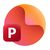

## Hiperparâmetros de regularização

O dataset **Moons** (`make_moons`) gera dois conjuntos de pontos em formato de meias-luas entrelaçadas — um problema de classificação binária não-linearmente separável, ideal para expor os limites de modelos que tendem ao **overfitting**.

Aqui treinamos dois modelos para comparação direta:

| Modelo | Configuração | Comportamento esperado |
|---|---|---|
| `tree_clf1` | Sem restrições (`max_depth=None`) | Cresce até separar perfeitamente os dados de treino → overfitting |
| `tree_clf2` | `min_samples_leaf=5` | Exige ao menos 5 amostras por folha → fronteiras mais suaves e generalizáveis |

O parâmetro `min_samples_leaf` é uma forma de **regularização**: ao impedir a criação de folhas com poucos exemplos, o modelo deixa de memorizar ruídos e aprende padrões mais robustos.

In [ ]:
# Importa o gerador de dados sintéticos em formato de meias-luas
from sklearn.datasets import make_moons


# Gera 150 amostras com ruído gaussiano (noise=0.2) para tornar o problema
# mais realista; random_state=42 garante reprodutibilidade
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)


# Modelo sem regularização: cresce livremente até pureza total das folhas
# Tende a criar fronteiras de decisão muito complexas (overfitting)
tree_clf1 = DecisionTreeClassifier(random_state=42)

# Modelo regularizado: cada folha deve conter no mínimo 5 amostras
# Isso limita a profundidade implicitamente e suaviza a fronteira de decisão
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

# Treina ambos os modelos no mesmo conjunto de dados para comparação justa
tree_clf1.fit(X_moons, y_moons)

In [ ]:
tree_clf2.fit(X_moons, y_moons)

Para visualizar o impacto da regularização, definimos uma função auxiliar `plot_decision_boundary()` que generaliza o processo de plotagem da fronteira de decisão para qualquer classificador binário. Em seguida, aplicamos ela aos dois modelos treinados anteriormente, lado a lado.

In [ ]:
def plot_decision_boundary(clf, X, y, axes, cmap):
    # Cria uma grade densa de pontos cobrindo os limites definidos em 'axes'
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))

    # Reformata a grade em um array 2D (N x 2) para alimentar o modelo
    X_new = np.c_[x1.ravel(), x2.ravel()]

    # Prediz a classe de cada ponto da grade e restaura o formato matricial
    y_pred = clf.predict(X_new).reshape(x1.shape)

    # Preenche as regiões de decisão com cores suaves (alpha=0.3)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)

    # Desenha a linha de fronteira entre as regiões com contorno cinza
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)

    # Define as cores dos pontos para cada colormap suportado
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}

    # Marcadores distintos para cada classe: círculo (classe 0) e triângulo (classe 1)
    markers = ("o", "^")

    # Plota os pontos reais do dataset, separando por classe (idx = 0 ou 1)
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")

    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)


# Cria dois subplots lado a lado com altura compartilhada (sharey=True)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# --- Painel esquerdo: árvore sem regularização ---
plt.sca(axes[0])  # Define o subplot ativo como o da esquerda
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("Sem restrições")

# --- Painel direito: árvore com min_samples_leaf=5 ---
plt.sca(axes[1])  # Define o subplot ativo como o da direita
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
# Exibe dinamicamente o valor do hiperparâmetro usado no título
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")  # Remove o rótulo do eixo y do painel direito (compartilhado)

plt.show()

Após o treinamento, é fundamental avaliar o modelo com dados **nunca vistos** — o conjunto de teste. O método `score()` retorna a **acurácia**, ou seja, a proporção de amostras classificadas corretamente.

Aqui geramos um conjunto de teste com 1.000 amostras (usando `random_state=43`, diferente do treino) e avaliamos o `tree_clf1` — a árvore **sem regularização**. A expectativa é que sua acurácia seja inferior à do `tree_clf2`, pois memorizou os dados de treino em vez de aprender padrões generalizáveis.

> 💡 O uso de `random_state` diferente entre treino (`42`) e teste (`43`) simula adequadamente a chegada de novos dados, garantindo uma avaliação honesta do modelo.

In [ ]:
# Gera 1.000 novas amostras com o mesmo nível de ruído do treino (noise=0.2)
# random_state=43 garante que os dados de teste sejam diferentes dos de treino
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)

# Avalia a acurácia do modelo sem restrições nos dados de teste
# score() = proporção de predições corretas = accuracy
# Valor esperado menor que o de tree_clf2, evidenciando o overfitting
tree_clf1.score(X_moons_test, y_moons_test)

Agora avaliamos o `tree_clf2` — a árvore com `min_samples_leaf=5` — no mesmo conjunto de teste, permitindo uma **comparação direta e justa** com o modelo sem restrições.

In [ ]:
# Avalia a acurácia do modelo regularizado (min_samples_leaf=5) no conjunto de teste
# Resultado esperado: ~0.92 — superior ao tree_clf1 (~0.898)
# Isso demonstra que a regularização reduziu o overfitting e melhorou a generalização
tree_clf2.score(X_moons_test, y_moons_test)

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Implemente uma função que treina três `DecisionTreeClassifier` no dataset Iris completo (todas as 4 features) com `max_depth` = 1, 3 e 5. A função deve retornar o número de folhas (`get_n_leaves()`) nesta mesma ordem.



In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

def get_leaves():
  """Calcula o número de folhas para três classificadores"""
  # Seu código aqui

In [ ]:
leaves1, leaves3, leaves5 = get_leaves()
assert leaves1 == 2
assert leaves3 == 5
assert leaves5 == 9
assert leaves1 < leaves3 < leaves5
print("Teste passado!")

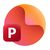

## Regressão

Além da classificação, as Árvores de Decisão também podem resolver problemas de **regressão** — ou seja, prever valores contínuos. O `DecisionTreeRegressor` funciona de forma análoga ao classificador: em vez de prever uma classe, cada folha prediz a **média dos valores-alvo** das amostras de treino que chegaram até ela.

Neste exemplo, geramos dados sintéticos de uma função quadrática $y = x^2$ com ruído gaussiano adicionado, simulando uma situação realista onde os dados seguem um padrão subjacente com variações aleatórias.

> 💡 O critério padrão de divisão dos nós na regressão é o **MSE** (Erro Quadrático Médio): o modelo escolhe o corte que minimiza a variância dos valores-alvo nos subgrupos resultantes.

In [ ]:
# Importa o regressor baseado em Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)  # Garante reprodutibilidade da geração de dados aleatórios

# Gera 200 amostras com uma única feature uniformemente distribuída em [-0.5, 0.5)
X_quad = np.random.rand(200, 1) - 0.5

# Define o alvo como uma função quadrática com ruído gaussiano:
# y = x² + ruído (noise ~ N(0, 0.025))
# O ruído simula variações reais e impede que os dados sejam perfeitamente ajustáveis
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)


# Instancia o regressor com profundidade máxima de 2 níveis
# max_depth=2 → o modelo terá no máximo 4 folhas, cada uma prevendo a média local de y
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)

# Treina o modelo: aprende os limiares de divisão que minimizam o MSE em cada nó
tree_reg.fit(X_quad, y_quad)

In [ ]:
export_graphviz(
    tree_reg,
    out_file=str("regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("regression_tree.dot")

Para avaliar o impacto da profundidade no ajuste da curva de regressão, treinamos um segundo modelo com `max_depth=3` — um nível a mais que o `tree_reg` anterior. Com isso, o modelo pode realizar **até 8 divisões nas folhas** (2³), capturando variações mais finas da função quadrática subjacente.

A comparação entre os dois modelos permite visualizar o *trade-off* clássico entre **viés e variância**:

| Modelo | `max_depth` | Nº máx. de folhas | Comportamento |
|---|---|---|---|
| `tree_reg` | 2 | 4 | Aproximação mais grosseira (alto viés) |
| `tree_reg2` | 3 | 8 | Aproximação mais refinada (menor viés) |

À medida que `max_depth` cresce, a curva predita se aproxima mais dos dados de treino — mas aumenta o risco de overfitting se não houver regularização adequada.

In [ ]:
# Instancia um segundo regressor com profundidade máxima de 3 níveis
# Um nível a mais que tree_reg permite subdivisões adicionais do espaço de entrada,
# resultando em uma curva de previsão mais próxima dos dados de treino
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)

# Treina nos mesmos dados de tree_reg, permitindo comparação direta entre profundidades
tree_reg2.fit(X_quad, y_quad)

Após o treinamento, é possível **inspecionar a estrutura interna** da árvore por meio do atributo `tree_`, que expõe os detalhes de cada nó. O sub-atributo `.threshold` retorna um array com os **valores de corte** utilizados em cada nó de divisão.

Nós folha (sem divisão) recebem o valor sentinela `-2.0` para indicar que não há limiar associado. Para uma árvore com `max_depth=2`, o array terá **7 posições** (2³ - 1 nós no total):

| Posição | Tipo de nó | Valor |
|---|---|---|
| Índice com valor real | Nó de divisão | Limiar $x \leq \theta$ |
| Índice com `-2.0` | Folha | Sem divisão |

> 💡 Esse recurso é especialmente útil para extrair e plotar manualmente as linhas de corte no gráfico da fronteira de decisão, como fizemos anteriormente com `tree_clf_deeper`.

In [ ]:
# Acessa o objeto interno que representa a estrutura da árvore treinada
# tree_ expõe atributos como: threshold, feature, value, n_node_samples, etc.
# .threshold retorna um array com o limiar de divisão de cada nó:
#   - nós de divisão: valor real (ex: 0.045) que define o corte x <= threshold
#   - nós folha: recebem o valor sentinela -2.0 (sem divisão)
tree_reg.tree_.threshold

In [ ]:
tree_reg2.tree_.threshold

Para entender como a profundidade afeta o ajuste do modelo, plotamos lado a lado as predições dos dois regressores treinados. A função auxiliar `plot_regression_predictions()` traça a **curva predita** (linha vermelha) sobre os **dados reais** (pontos azuis), tornando a comparação direta e intuitiva.

In [ ]:
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    # Cria 500 pontos igualmente espaçados no intervalo dos eixos para uma curva suave
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)

    # Gera a predição do modelo para cada ponto da grade contínua
    y_pred = tree_reg.predict(x1)

    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")                                          # Dados reais em azul
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$") # Predições em vermelho


fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# ── Painel esquerdo: max_depth=2 ──────────────────────────────────────────────
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

# Extrai os limiares dos nós de profundidade 0 e 1 pelo índice interno da árvore
th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]

# Plota as linhas verticais de corte: sólida (depth=0) e tracejadas (depth=1)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)

# Anotações textuais indicando a profundidade de cada linha de corte
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)

plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")


# ── Painel direito: max_depth=3 ───────────────────────────────────────────────
plt.sca(axes[1])

# Extrai os limiares de profundidade 2 da árvore mais profunda (4 cortes adicionais)
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]

plot_regression_predictions(tree_reg2, X_quad, y_quad)

# Reutiliza as mesmas linhas de depth=0 e depth=1 para manter a consistência visual
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)

# Adiciona as linhas pontilhadas dos cortes de profundidade 2
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)

plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

In [ ]:
tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("Sem restrições")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")
plt.show()

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Um `DecisionTreeRegressor` **sem restrições** é capaz de memorizar os dados de treinamento. Treine um regressor sem `max_depth` no mesmo dataset `X_quad`/`y_quad` usado no notebook, gerado usando o código:

```python
np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)
```

Sua função deve trinar o regressor sem restrições e um segundo regressor com `min_samples_leaf=10`. A função deve retornar o R² no treino dos dois regressores.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

def calcula_r2():
  """Calcula o R2 de dois regressores (sem e com restrição)"""
  # Seu código aqui

In [ ]:
import math

r2_sem_restricao, r2_regularizado = calcula_r2()
assert r2_sem_restricao == 1.0
assert math.isclose(r2_regularizado, 0.921, rel_tol=1e-3)
print("Teste passado!")

## Sensibilidade à orientação do eixo

Uma limitação importante das Árvores de Decisão é que suas fronteiras são **sempre paralelas aos eixos** — cada nó realiza um corte do tipo $x_i \leq \theta$. Isso significa que o modelo pode ter dificuldades quando os dados possuem estruturas **diagonais ou rotacionadas**.

Neste experimento, criamos um dataset simples onde a fronteira de decisão natural é vertical (em $x_1 = 0$) e treinamos dois modelos:

| Modelo | Dados | Resultado esperado |
|---|---|---|
| `tree_clf_square` | Original (eixos alinhados) | Fronteira limpa com um único corte vertical |
| `tree_clf_rotated_square` | Rotacionado 45° | Fronteira escalonada e complexa para aproximar uma diagonal |

In [ ]:
np.random.seed(6)

# Gera 100 amostras 2D uniformemente distribuídas em [-0.5, 0.5)
X_square = np.random.rand(100, 2) - 0.5

# Rótulo binário: classe 1 se x1 > 0, classe 0 caso contrário
# A fronteira de decisão natural é uma linha vertical em x1 = 0
y_square = (X_square[:, 0] > 0).astype(np.int64)


angle = np.pi / 4  # Ângulo de rotação: 45 graus em radianos

# Matriz de rotação 2D: gira todos os pontos em 45° no sentido anti-horário
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])

# Aplica a rotação: cada ponto (linha de X_square) é multiplicado pela matriz
# O produto matricial desloca a fronteira natural para uma diagonal de 45°
X_rotated_square = X_square.dot(rotation_matrix)


# Modelo treinado nos dados originais (fronteira alinhada ao eixo x1)
tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)

# Modelo treinado nos dados rotacionados (fronteira diagonal)
# A árvore tentará aproximar a diagonal com cortes paralelos aos eixos → fronteira escalonada
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)


fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# ── Painel esquerdo: dados originais ─────────────────────────────────────────
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")

# ── Painel direito: dados rotacionados 45° ────────────────────────────────────
plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.ylabel("")  # Remove rótulo do eixo y (compartilhado com o painel esquerdo)

plt.show()

Como vimos na célula anterior, Árvores de Decisão sofrem com dados em orientações diagonais. Uma solução elegante é aplicar **PCA (Análise de Componentes Principais)** antes do treinamento: o PCA realiza uma rotação nos dados de forma que as novas features (componentes principais) fiquem **alinhadas com as direções de maior variância**, facilitando a criação de fronteiras eficientes.

In [ ]:
# Importa o PCA para redução/rotação dimensional
from sklearn.decomposition import PCA

# make_pipeline encadeia transformações e o modelo em uma sequência automática
from sklearn.pipeline import make_pipeline

# StandardScaler padroniza as features (média=0, variância=1)
from sklearn.preprocessing import StandardScaler

# Cria o pipeline de pré-processamento:
# 1º) StandardScaler: normaliza os dados (PCA é sensível à escala)
# 2º) PCA: rotaciona os dados alinhando os eixos às direções de maior variância
pca_pipeline = make_pipeline(StandardScaler(), PCA())

# Aplica o pipeline ao dataset Iris (apenas as 2 features de pétala)
# fit_transform: ajusta o scaler e o PCA, e já retorna os dados transformados
X_iris_rotated = pca_pipeline.fit_transform(X_iris)

# Treina a Árvore de Decisão no espaço rotacionado pelo PCA
# Com max_depth=2, o modelo cria fronteiras paralelas aos componentes principais
# que agora coincidem com as direções de maior separabilidade entre as classes
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

In [ ]:
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))
plt.show()

### Árvores de decisão apresentam alta variância

Vimos que pequenas alterações no conjunto de dados (como uma rotação) podem produzir uma Árvore de Decisão muito diferente.
Agora, vamos mostrar que treinar o mesmo modelo com os mesmos dados pode produzir um modelo muito diferente a cada vez, já que o algoritmo de treinamento CART usado pelo Scikit-Learn é estocástico. Para mostrar isso, definiremos `random_state` para um valor diferente do anterior:

In [ ]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

In [ ]:
plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()
plt.show()

### Acessando a estrutura da árvore

Um `DecisionTreeClassifier` treinado possui um atributo `tree_` que armazena a estrutura da árvore:

In [ ]:
tree = tree_clf.tree_
tree

Você pode obter o número total de nós na árvore:

In [ ]:
tree.node_count

E outros atributos autoexplicativos estão disponíveis:

In [ ]:
tree.max_depth

In [ ]:
tree.max_n_classes

In [ ]:
tree.n_features

In [ ]:
tree.n_outputs

In [ ]:
int(tree.n_leaves)

Todas as informações sobre os nós são armazenadas em arrays NumPy. Por exemplo, a impureza de cada nó:

In [ ]:
tree.impurity

O nó raiz está no índice 0. Os nós filhos esquerdo e direito do nó _i_ são `tree.children_left[i]` e `tree.children_right[i]`. Por exemplo, os filhos do nó raiz são:

In [ ]:
int(tree.children_left[0]), int(tree.children_right[0])

Quando os nós da esquerda e da direita são iguais, significa que este é um nó folha (e os IDs dos nós filhos são arbitrários):

In [ ]:
int(tree.children_left[3]), int(tree.children_right[3])

Assim, você pode obter os IDs dos nós folha desta forma:

In [ ]:
is_leaf = (tree.children_left == tree.children_right)
np.arange(tree.node_count)[is_leaf]

Os nós que não são folhas são chamados de _nós divididos_. A característica que eles dividem está disponível através do array `feature`. Os valores dos nós folha devem ser ignorados.

In [ ]:
tree.feature

E os respectivos limiares são:

In [ ]:
tree.threshold

E o número de instâncias por classe que alcançaram cada nó também está disponível:

In [ ]:
tree.value

In [ ]:
tree.n_node_samples

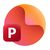

## Classificadores de votação

Este experimento simula **10 sequências independentes de 10.000 lançamentos** de uma moeda levemente viciada (51% de chance de cara), ilustrando a **Lei dos Grandes Números**: à medida que o número de observações cresce, a média amostral converge para a média real da população.

Essa simulação é a **intuição fundamental por trás dos métodos de Ensemble** (como o Random Forest): mesmo que cada modelo individual seja apenas *ligeiramente* melhor que o acaso, a **agregação de muitos modelos independentes** tende a convergir para a resposta correta de forma confiável.

> 💡 No contexto de ensemble: se cada classificador acerta com probabilidade de 51%, um conjunto de 10.000 classificadores votando em maioria acerta com probabilidade próxima de 100% — desde que os erros sejam **independentes** entre si.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


heads_proba = 0.51  # Probabilidade de cara: moeda levemente viciada (51%)

np.random.seed(42)

# Gera uma matriz (10000 lançamentos) x (10 sequências independentes)
# Cada elemento é 1 (cara) se o valor aleatório < 0.51, ou 0 (coroa) caso contrário
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)

# Acumula o total de caras ao longo dos lançamentos (eixo 0 = ao longo das linhas)
cumulative_heads = coin_tosses.cumsum(axis=0)

# Calcula a proporção acumulada de caras a cada lançamento
# np.arange(1, 10001).reshape(-1, 1) divide cada linha pelo número do lançamento atual
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)


plt.figure(figsize=(8, 3.5))

# Plota as 10 curvas de proporção acumulada (uma cor por sequência)
plt.plot(cumulative_heads_ratio)

# Linha de referência tracejada: probabilidade real da moeda (51%)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")

# Linha de referência sólida: probabilidade de uma moeda justa (50%)
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")

plt.xlabel("Número de lançamentos de moedas")
plt.ylabel("Taxa de Caras")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])  # Limita o eixo y para destacar a convergência
plt.grid()
plt.show()

O **Voting Classifier** é a forma mais direta de ensemble: treina múltiplos modelos independentes e combina suas previsões por **votação majoritária** (hard voting) — a classe que receber mais votos vence. A ideia é que modelos com tipos de erro diferentes se compensem mutuamente, resultando em maior acurácia geral.

> 💡 A diversidade entre os modelos base é um fator crítico para o sucesso de um ensemble: classificadores que erram nas **mesmas amostras** não trazem ganho real ao votar juntos.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC


# Gera 500 amostras do dataset Moons com ruído moderado (noise=0.30)
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

# Divide em treino (75%) e teste (25%) de forma estratificada e reprodutível
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


# Instancia o VotingClassifier com três modelos base heterogêneos:
# - LogisticRegression: modelo linear, rápido e interpretável
# - RandomForestClassifier: ensemble de árvores, captura relações não-lineares
# - SVC: maximiza a margem de separação, robusto em espaços de alta dimensão
# voting="hard" (padrão): cada modelo emite um voto e a classe majoritária vence
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)

# Treina os três modelos simultaneamente sobre os dados de treino
voting_clf.fit(X_train, y_train)

Antes de verificar o desempenho do ensemble como um todo, é importante avaliar cada modelo base separadamente. Isso permite confirmar se o `VotingClassifier` de fato supera seus componentes individuais — o que justifica o uso do ensemble.

O atributo `named_estimators_` expõe os modelos já treinados como um dicionário `{nome: modelo}`, permitindo iterar sobre eles de forma direta. O resultado esperado é que nenhum modelo isolado supere o ensemble, evidenciando o ganho coletivo da votação majoritária.

In [ ]:
# Itera sobre os modelos base já treinados dentro do VotingClassifier
# named_estimators_ é um dicionário {sigla: modelo_treinado}
# Ex: {'lr': LogisticRegression(...), 'rf': RandomForestClassifier(...), 'svc': SVC(...)}
for name, clf in voting_clf.named_estimators_.items():

    # Avalia a acurácia de cada modelo individualmente no conjunto de teste
    # Permite comparar o desempenho de cada componente com o do ensemble
    print(name, "=", clf.score(X_test, y_test))

Para inspecionar o funcionamento do `VotingClassifier` na prática, aplicamos `predict()` à **primeira amostra do conjunto de teste**. No modo padrão de **hard voting**, o ensemble coleta o voto de cada modelo base e retorna a classe que obteve a maioria dos votos.

Para uma amostra com 3 votantes, a decisão segue a lógica:

| Cenário | Votos | Classe predita |
|---|---|---|
| Unanimidade | 3 × classe X | X |
| Maioria simples | 2 × classe X, 1 × classe Y | X |
| Empate | — | Impossível com número ímpar de modelos |

> 💡 Usar um número **ímpar** de modelos base é uma boa prática em hard voting, pois elimina a possibilidade de empate na votação.

In [ ]:
# Aplica o VotingClassifier à primeira amostra do conjunto de teste (shape: 1 x 2)
# Internamente, cada modelo base emite um voto (hard voting)
# O ensemble retorna a classe que recebeu a maioria dos votos entre lr, rf e svc
voting_clf.predict(X_test[:1])

Para entender como o ensemble chegou à sua decisão na célula anterior, podemos consultar a predição de **cada modelo base separadamente**. O atributo `estimators_` (sem o `named_`) retorna uma lista ordenada dos modelos treinados, na mesma ordem em que foram declarados: `[lr, rf, svc]`.

Isso torna o processo de votação completamente **transparente e auditável** — é possível verificar exatamente quais modelos concordaram e qual eventualmente divergiu, explicando o voto final do ensemble.

> 💡 **Diferença entre os atributos:**
> - `named_estimators_` → dicionário `{nome: modelo}` — útil para acessar por nome
> - `estimators_` → lista `[modelo1, modelo2, ...]` — útil para iterar em ordem

In [ ]:
# Itera sobre a lista ordenada de modelos base já treinados: [lr, rf, svc]
# Para cada modelo, prediz a classe da primeira amostra de teste individualmente
# O resultado é uma lista com os 3 votos que compõem a decisão do ensemble
# Ex: [array([1]), array([1]), array([0])] → 2 votos para classe 1 → ensemble prediz 1
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

Com os modelos base avaliados individualmente, chegamos à avaliação do `VotingClassifier` como um todo. Essa é a métrica que confirma (ou refuta) a hipótese central do ensemble: **a combinação de modelos diversos supera qualquer modelo isolado**.

O resultado esperado é uma acurácia superior à de todos os modelos base avaliados anteriormente, demonstrando o ganho real obtido pela votação majoritária.

In [ ]:
# Avalia a acurácia do VotingClassifier completo no conjunto de teste
# Combina os votos de lr, rf e svc por maioria simples (hard voting)
# Resultado esperado: acurácia superior à de qualquer modelo base individual
voting_clf.score(X_test, y_test)

O modo **soft voting** é geralmente mais poderoso que o hard voting: em vez de contar votos binários, ele **média as probabilidades** estimadas por cada modelo para cada classe e prediz a classe com maior probabilidade média.

A diferença entre os dois modos:

| Modo | Mecanismo | Quando usar |
|---|---|---|
| **Hard voting** | Maioria dos votos (0 ou 1) | Quando os modelos não suportam `predict_proba` |
| **Soft voting** | Média das probabilidades | Quando todos os modelos fornecem probabilidades calibradas |

Uma atenção especial é necessária com o `SVC`: por padrão, ele **não estima probabilidades** (o que aceleraria o treinamento). Para ativá-las, é preciso definir `probability=True` antes de (re)treinar o modelo, pois isso adiciona internamente uma calibração via validação cruzada.

> ⚠️ Como `probability=True` muda a configuração do SVC, o `VotingClassifier` precisa ser **retreinado** com `fit()` para que a mudança tenha efeito.

In [ ]:
# Altera o modo de votação de "hard" para "soft"
# No soft voting, o ensemble média as probabilidades de cada classe entre os modelos
voting_clf.voting = "soft"

# Ativa a estimativa de probabilidades no SVC
# Por padrão, SVC não computa probabilidades (probability=False) por questão de desempenho
# Com probability=True, o sklearn usa validação cruzada interna (Platt scaling) para calibrá-las
# IMPORTANTE: essa alteração só surte efeito após um novo treinamento
voting_clf.named_estimators["svc"].probability = True

# Retreina o ensemble completo com a nova configuração
# Necessário porque o SVC precisa recalcular as probabilidades calibradas
voting_clf.fit(X_train, y_train)

# Avalia o soft voting no conjunto de teste
# Resultado esperado: acurácia superior ao hard voting, pois usa informação mais rica
voting_clf.score(X_test, y_test)

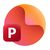

## Bagging e Pasting

O **Bagging** (*Bootstrap Aggregating*) é uma técnica de ensemble que treina múltiplos modelos base **em paralelo**, cada um sobre um subconjunto diferente dos dados de treino amostrado **com reposição** (*bootstrap*). As predições finais são combinadas por votação majoritária (classificação) ou média (regressão).

A principal diferença em relação ao `VotingClassifier` está na origem da diversidade entre os modelos:

| Técnica | Fonte de diversidade | Modelos base |
|---|---|---|
| **Voting** | Algoritmos diferentes | Heterogêneos |
| **Bagging** | Subconjuntos diferentes dos dados | Homogêneos |

> 💡 Como cada modelo vê apenas uma parte dos dados, o Bagging reduz a **variância** do modelo final sem aumentar o viés — sendo especialmente eficaz com modelos de alta variância como Árvores de Decisão sem restrições.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


# Instancia o BaggingClassifier com Árvores de Decisão como modelo base:
# - DecisionTreeClassifier(): modelo base sem restrições (alta variância, ideal para bagging)
# - n_estimators=500: treina 500 árvores independentes
# - max_samples=100: cada árvore é treinada em 100 amostras sorteadas com reposição
# - n_jobs=-1: paraleliza o treinamento usando todos os núcleos de CPU disponíveis
# - random_state=42: garante reprodutibilidade dos subconjuntos amostrados
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)

# Treina as 500 árvores em paralelo, cada uma sobre um bootstrap diferente de X_train
bag_clf.fit(X_train, y_train)

In [ ]:
def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Árvore de decisão")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Árvore de decisão com Bagging")
plt.ylabel("")
plt.show()

### Avaliação Out-of-Bag

Uma vantagem exclusiva do Bagging é a possibilidade de avaliar o modelo **sem usar um conjunto de validação separado**, por meio do **OOB score** (Out-of-Bag). Como cada árvore é treinada em ~63% das amostras (bootstrap com reposição), os ~37% restantes — que nunca foram vistos por aquela árvore — funcionam como um conjunto de teste natural.

O OOB score é calculado da seguinte forma:

1. Para cada amostra de treino, identifica quais árvores **não** a usaram no treinamento
2. Faz a predição usando **apenas essas árvores**
3. Compara com o rótulo real e calcula a acurácia média

Isso equivale a uma **validação cruzada gratuita**, sem custo computacional adicional, já embutida no processo de treinamento.

> ⚠️ Nesta célula, `max_samples` foi removido para que cada árvore use o conjunto completo de treino como base do bootstrap (tamanho padrão = `len(X_train)`), maximizando a quantidade de amostras OOB disponíveis para avaliação.

In [ ]:
# Reinstancia o BaggingClassifier agora com oob_score=True
# oob_score=True: ativa a avaliação automática nas amostras out-of-bag
# max_samples removido: cada bootstrap usa len(X_train) amostras (com reposição)
# garantindo ~37% de amostras OOB por árvore para avaliação
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)

# Treina as 500 árvores e, ao final, computa automaticamente o OOB score
bag_clf.fit(X_train, y_train)

# Exibe a acurácia OOB: estimativa não-enviesada do erro de generalização
# Resultado esperado: próximo da acurácia real no conjunto de teste
bag_clf.oob_score_

Após estimar o desempenho via OOB score, avaliamos o modelo com os dados de teste reais usando `accuracy_score`. Essa comparação valida a confiabilidade do OOB como estimador de generalização — se os dois valores forem próximos, o OOB score cumpriu bem seu papel.

| Métrica | Base de cálculo | Resultado esperado |
|---|---|---|
| `oob_score_` | ~37% das amostras de treino não vistas por cada árvore | ~93% |
| `accuracy_score` | Conjunto de teste separado (`X_test`) | ~93% |

A proximidade entre os dois valores confirma que o OOB score é uma **estimativa confiável e gratuita** do erro de generalização — dispensando a necessidade de um conjunto de validação separado em muitos cenários práticos.

In [ ]:
from sklearn.metrics import accuracy_score


# Gera as predições do BaggingClassifier para todo o conjunto de teste
# Internamente, cada uma das 500 árvores vota e a classe majoritária é retornada
y_pred = bag_clf.predict(X_test)

# Calcula a acurácia comparando predições com os rótulos reais do teste
# Permite comparar diretamente com o oob_score_ obtido na célula anterior
# Resultado esperado: próximo ao oob_score_, validando a estimativa OOB
accuracy_score(y_test, y_pred)

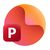

## Florestas Aleatórias

O **Random Forest** é uma evolução do Bagging aplicado a Árvores de Decisão, com um diferencial fundamental: além de amostrar os dados com bootstrap, ele também introduz **aleatoriedade na seleção de features** em cada divisão de nó. Em vez de considerar todas as features disponíveis, cada nó avalia apenas um subconjunto aleatório de tamanho `√n_features`.

Essa dupla aleatoriedade — nos dados **e** nas features — gera árvores ainda mais diversas entre si, reduzindo a correlação entre elas e, consequentemente, diminuindo ainda mais a variância do ensemble.

| Técnica | Aleatoriedade nos dados | Aleatoriedade nas features |
|---|---|---|
| **Bagging** | ✅ Bootstrap | ❌ Avalia todas |
| **Random Forest** | ✅ Bootstrap | ✅ Subconjunto aleatório |

O parâmetro `max_leaf_nodes=16` limita o crescimento de cada árvore, controlando a complexidade individual dos modelos base e atuando como regularização implícita.

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Instancia o Random Forest com os seguintes hiperparâmetros:
# - n_estimators=500: treina 500 árvores com bootstrap + seleção aleatória de features
# - max_leaf_nodes=16: limita cada árvore a no máximo 16 folhas (regularização)
# - n_jobs=-1: paraleliza o treinamento em todos os núcleos de CPU disponíveis
# - random_state=42: garante reprodutibilidade dos subconjuntos amostrados
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)

# Treina o ensemble: cada árvore recebe um bootstrap de X_train e,
# em cada nó, avalia apenas √n_features features escolhidas aleatoriamente
rnd_clf.fit(X_train, y_train)

# Gera as predições para o conjunto de teste via votação majoritária entre as 500 árvores
y_pred_rf = rnd_clf.predict(X_test)

O `RandomForestClassifier` do scikit-learn é essencialmente um `BaggingClassifier` otimizado. Para evidenciar essa equivalência, é possível **reproduzir o comportamento do Random Forest manualmente** combinando dois parâmetros-chave diretamente no `DecisionTreeClassifier`.

Essa equivalência é didaticamente importante: deixa explícito que o Random Forest **não é um algoritmo radicalmente novo**, mas sim uma combinação bem projetada de Bagging com injeção de aleatoriedade nas features. Na prática, o `RandomForestClassifier` é preferido por ser mais eficiente computacionalmente.

In [ ]:
# Replica o comportamento de um Random Forest usando BaggingClassifier explicitamente:
# - max_features="sqrt": em cada nó, avalia apenas √n_features features sorteadas
#   aleatoriamente — principal diferencial do Random Forest em relação ao Bagging puro
# - max_leaf_nodes=16: restringe o crescimento da árvore, equivalente ao RandomForestClassifier
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500,   # 500 árvores — mesmo valor usado no RandomForestClassifier anterior
    n_jobs=-1,          # Paraleliza o treinamento em todos os núcleos disponíveis
    random_state=42     # Garante reprodutibilidade para comparação direta com rnd_clf
)

Para confirmar que a implementação manual com `BaggingClassifier` é funcionalmente equivalente ao `RandomForestClassifier`, comparamos diretamente as predições dos dois modelos amostra a amostra. O operador `np.all()` retorna `True` apenas se **todas** as predições forem idênticas.

In [ ]:
# Treina o BaggingClassifier manual com os mesmos dados de treino
bag_clf.fit(X_train, y_train)

# Gera as predições do BaggingClassifier manual para o conjunto de teste
y_pred_bag = bag_clf.predict(X_test)

# Compara elemento a elemento as predições do BaggingClassifier manual (y_pred_bag)
# com as predições do RandomForestClassifier (y_pred_rf) obtidas na célula anterior
# np.all() retorna True somente se TODAS as predições forem idênticas
np.all(y_pred_bag == y_pred_rf)  # mesmas previsões

### Importância da característica

Uma das vantagens mais valiosas do Random Forest é a capacidade de estimar a **importância relativa de cada feature** para as predições do modelo. O atributo `feature_importances_` mede, para cada feature, o quanto ela contribui para a **redução média da impureza** (Gini ou entropia) ao longo de todas as árvores e todos os nós onde foi utilizada.

> ⚠️ A importância baseada em impureza pode ser enviesada para features com alta cardinalidade. Para análises críticas, considere `permutation_importance` como alternativa mais robusta.

In [ ]:
from sklearn.datasets import load_iris

# Recarrega o dataset Iris completo com todas as 4 features (como DataFrame)
iris = load_iris(as_frame=True)

# Instancia e treina um novo Random Forest com todas as features do Iris
# n_estimators=500: 500 árvores para uma estimativa estável de importância
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)

# Itera sobre os scores de importância e os nomes das features em paralelo
# feature_importances_: array com a redução média de impureza por feature,
# normalizado para que a soma de todos os valores seja igual a 1 (100%)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Implemente a função `gini_impurity(class_counts)` que recebe uma lista com o número de amostras por classe em um nó e retorna a impureza de Gini, dada por:

$$G = 1 - \sum_{k} p_k^2$$

onde $p_k$ é a proporção de amostras da classe $k$ no nó.



In [ ]:
def gini_impurity(class_counts):
  """Calcula o índice de impureza de Gini"""
  # Seu código aqui

In [ ]:
import math

gi = gini_impurity([50, 50])
assert gi == 0.5
gi = gini_impurity([100, 0])
assert gi == 0.0
gi = gini_impurity([25,25,25,25])
assert gi == 0.75
gi = gini_impurity([10,90])
assert math.isclose(gi, 0.1799, rel_tol=1e-3)
print("Teste passado!")

O dataset **MNIST** contém imagens de dígitos manuscritos com resolução de 28×28 pixels — representados como vetores de 784 features (um valor por pixel). Ao treinar um Random Forest nesse dataset, o atributo `feature_importances_` retorna um vetor de 784 valores que, ao ser **redimensionado para 28×28**, forma um mapa de calor revelando quais regiões da imagem o modelo considera mais informativas.

O resultado visual confirma uma intuição geométrica importante: os **pixels centrais** da imagem têm maior importância, pois é onde os traços dos dígitos se concentram, enquanto as bordas — geralmente em branco — contribuem muito pouco para a classificação.

> ⚠️ O treinamento com 70.000 amostras e 784 features pode ser demorado. Para acelerar, considere usar `n_jobs=-1` (paralelismo total) ou reduzir `n_estimators`.

In [ ]:
# Importa a função para baixar o dataset MNIST do OpenML (70.000 imagens 28x28)
from sklearn.datasets import fetch_openml


# Baixa o MNIST: X tem shape (70000, 784) e y os rótulos de 0 a 9
# as_frame=False: retorna arrays NumPy (mais eficiente para imagens)
# parser='auto': seleciona automaticamente o parser mais adequado
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')


# Treina o Random Forest com 100 árvores sobre todas as 70.000 amostras
# Cada feature corresponde a um pixel da imagem (784 no total)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)


# Redimensiona o vetor de importâncias (784,) para o formato da imagem (28x28)
# Isso mapeia cada score de importância de volta ao pixel correspondente
heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)

# Exibe o mapa de calor: pixels mais quentes (brancos/amarelos) = mais importantes
# cmap="hot": gradiente de preto (sem importância) → branco/amarelo (muito importante)
plt.imshow(heatmap_image, cmap="hot")

# Adiciona barra de cores com rótulos nos extremos de importância
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Não importante', 'Muito importante'], fontsize=14)

plt.axis("off")  # Remove os eixos pois os pixels não têm coordenadas significativas
plt.show()

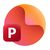

## Boosting

### AdaBoost

O **AdaBoost** (Adaptive Boosting) é uma técnica de ensemble do tipo *boosting*: ao contrário do Bagging (paralelo), os modelos são treinados **sequencialmente**, cada um focando nos erros do anterior. Isso é feito ajustando os **pesos das amostras**: a cada iteração, amostras classificadas erroneamente recebem peso maior, forçando o próximo classificador a se concentrar nelas.

A comparação entre `learning_rate=1` e `learning_rate=0.5` (parâmetro $\eta$) mostra o impacto da taxa de aprendizado: valores menores atualizam os pesos de forma mais conservadora, resultando em fronteiras que evoluem mais suavemente entre as iterações.

In [ ]:
m = len(X_train)  # Número total de amostras de treino

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

# Itera sobre os dois painéis, cada um com uma taxa de aprendizado diferente
for subplot, learning_rate in ((0, 1), (1, 0.5)):

    # Inicializa os pesos uniformemente: cada amostra começa com peso igual (1/m)
    sample_weights = np.ones(m) / m

    plt.sca(axes[subplot])

    # Executa 5 iterações do AdaBoost manualmente
    for i in range(5):

        # Treina o classificador base (SVM) com os pesos atuais das amostras
        # sample_weight * m: reescala os pesos para que a soma seja igual a m
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)


        # Calcula a taxa de erro ponderada: soma dos pesos das amostras mal classificadas
        # dividida pela soma total dos pesos (que é 1 após a normalização)
        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()

        # Calcula o peso (influência) deste classificador no ensemble final
        # α alto → classificador confiável; α baixo → classificador fraco
        alpha = learning_rate * np.log((1 - r) / r)

        # Aumenta o peso das amostras mal classificadas pelo fator e^α
        # Isso força o próximo classificador a focar nos erros atuais
        sample_weights[y_pred != y_train] *= np.exp(alpha)

        # Normaliza os pesos para que somem 1 (distribuição de probabilidade)
        sample_weights /= sample_weights.sum()  # etapa de normalização


        # Plota a fronteira de decisão do classificador atual (alpha=0.4 para semitransparência)
        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")

    # Numera visualmente as fronteiras no painel esquerdo para identificar cada iteração
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0,   -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5,  "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")  # Remove rótulo do eixo y no painel direito (compartilhado)


plt.show()

Após implementar o AdaBoost manualmente, utilizamos agora a implementação otimizada do scikit-learn via `AdaBoostClassifier`. O modelo base padrão e mais comum para AdaBoost é o **Decision Stump** — uma Árvore de Decisão com `max_depth=1` (apenas um nó de decisão e duas folhas), o classificador mais simples possível acima do acaso.

A escolha do Decision Stump não é acidental: o AdaBoost foi **projetado para modelos fracos** (*weak learners*). Ao combinar 30 stumps sequencialmente, cada um corrigindo os erros do anterior, o ensemble constrói uma fronteira de decisão progressivamente mais sofisticada.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier


# Instancia o AdaBoostClassifier com Decision Stumps como modelo base:
# - DecisionTreeClassifier(max_depth=1): classificador fraco com um único corte
# - n_estimators=30: encadeia 30 stumps sequencialmente
# - learning_rate=0.5: fator η que escala o peso α de cada stump no ensemble
#   → valores menores tornam o aprendizado mais conservador e reduzem overfitting
# - random_state=42: garante reprodutibilidade das amostras e divisões internas
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)

# Treina os 30 stumps sequencialmente:
# cada stump é ajustado com os pesos atualizados das amostras da iteração anterior
ada_clf.fit(X_train, y_train)

In [ ]:
# Caso você esteja curioso para ver como é o limite de decisão para o
# classificador AdaBoost
plot_decision_boundary(ada_clf, X_train, y_train)

### Gradient Boosting

O **Gradient Boosting** é uma técnica de boosting que, assim como o AdaBoost, treina modelos sequencialmente — mas com uma abordagem diferente: em vez de ajustar os pesos das amostras, cada novo modelo é treinado para **corrigir os resíduos** (erros) do modelo anterior.

A predição final é a **soma de todas as árvores**: $\hat{y} = h_1(x) + h_2(x) + h_3(x) + \ldots$

Nesta célula, geramos os dados sintéticos $y = 3x^2 + \varepsilon$ e treinamos a **primeira árvore** do ensemble, que servirá de base para as próximas iterações.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

# Gera 100 amostras com uma única feature uniformemente distribuída em [-0.5, 0.5)
X = np.random.rand(100, 1) - 0.5

# Define o alvo como uma parábola com ruído gaussiano leve:
# y = 3x² + ε, onde ε ~ N(0, 0.05)
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)


# Treina a PRIMEIRA árvore do Gradient Boosting diretamente sobre os rótulos originais (y)
# max_depth=2: árvore rasa para evitar overfitting individual (modelo fraco intencional)
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

Com a primeira árvore treinada, calculamos os **resíduos** — a diferença entre os valores reais e as predições de `tree_reg1`. Esses resíduos representam o que o modelo **ainda não conseguiu explicar**, e é exatamente sobre eles que a segunda árvore será treinada.

Matematicamente:

$$r_1 = y - h_1(x)$$

A segunda árvore $h_2(x)$ aprende a prever $r_1$, não mais $y$. Com isso, a predição combinada das duas árvores $h_1(x) + h_2(x)$ já será mais precisa que a primeira isolada, pois o ensemble corrigiu parte dos erros iniciais.

> 💡 Note o uso de `random_state=43` (diferente de 42) para garantir que as duas árvores sejam estruturalmente diferentes, evitando que `tree_reg2` repita exatamente as mesmas divisões de `tree_reg1`.

In [ ]:
# Calcula os resíduos da primeira árvore:
# y2 = y - ŷ₁ → o que tree_reg1 ainda não conseguiu prever corretamente
# Esses resíduos são o novo "alvo" para a segunda árvore do ensemble
y2 = y - tree_reg1.predict(X)

# Treina a SEGUNDA árvore diretamente sobre os resíduos (y2), não sobre y original
# random_state=43: garante estrutura diferente de tree_reg1 para maior diversidade
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

Continuando o processo sequencial, calculamos agora os **resíduos da segunda árvore** — o erro residual que permaneceu após a correção de `tree_reg2` — e treinamos uma terceira árvore para aprendê-los.

$$r_2 = r_1 - h_2(x) = y - h_1(x) - h_2(x)$$

A predição final do ensemble com as três árvores será:

$$\hat{y} = h_1(x) + h_2(x) + h_3(x)$$

A cada iteração, os resíduos tendem a **diminuir em magnitude**, pois cada nova árvore captura uma parcela do erro anterior. Esse processo de redução progressiva dos resíduos é a essência do Gradient Boosting — e é equivalente a descer o gradiente da função de perda MSE no espaço funcional.

In [ ]:
# Calcula os resíduos da segunda árvore:
# y3 = y2 - ŷ₂ → erro residual que tree_reg2 ainda não conseguiu capturar
# Equivalente a: y3 = y - h₁(x) - h₂(x)
y3 = y2 - tree_reg2.predict(X)

# Treina a TERCEIRA árvore sobre os resíduos de y2 (y3)
# random_state=44: mantém a diversidade estrutural entre as árvores do ensemble
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

Com as três árvores treinadas, a predição do Gradient Boosting para novos pontos é simplesmente a **soma das predições individuais** de cada árvore:

$$\hat{y} = h_1(x) + h_2(x) + h_3(x)$$

Testamos o ensemble com três novos pontos representativos do domínio:

| Ponto | $x$ | $y_{real} \approx 3x^2$ |
|---|---|---|
| 1 | -0.4 | 0.48 |
| 2 | 0.0 | 0.00 |
| 3 | 0.5 | 0.75 |

A soma das predições das três árvores deve aproximar esses valores reais, demonstrando que o ensemble construído manualmente convergiu para uma boa aproximação da função quadrática subjacente.

In [ ]:
# Define 3 novos pontos fora do conjunto de treino para testar o ensemble
X_new = np.array([[-0.4], [0.], [0.5]])

# Calcula a predição final do Gradient Boosting como a SOMA das predições individuais:
# ŷ = h₁(x) + h₂(x) + h₃(x)
# - tree_reg1 prediz sobre y original
# - tree_reg2 prediz sobre os resíduos de tree_reg1
# - tree_reg3 prediz sobre os resíduos de tree_reg2
# A soma reconstrói progressivamente a aproximação da função y = 3x²
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [ ]:
def plot_predictions(regressors, X, y, axes, style,
                     label=None, data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1))
                 for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center")
    plt.axis(axes)

plt.figure(figsize=(11, 11))

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="g-",
                 label="$h_1(x_1)$", data_label="Dados de treinamento")
plt.ylabel("$y$  ", rotation=0)
plt.title("Residuais e previsões de árvores")

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1)$", data_label="Dados de treinamento")
plt.title("Previsões do Conjunto")

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_2(x_1)$", data_style="k+",
                 data_label="Residuais: $y - h_1(x_1)$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.2, 0.8],
                  style="r-", label="$h(x_1) = h_1(x_1) + h_2(x_1)$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.4, 0.6], style="g-",
                 label="$h_3(x_1)$", data_style="k+",
                 data_label="Residuais: $y - h_1(x_1) - h_2(x_1)$")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)

plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y,
                 axes=[-0.5, 0.5, -0.2, 0.8], style="r-",
                 label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$")
plt.show()

Após implementar o Gradient Boosting manualmente nas três células anteriores, utilizamos agora a implementação otimizada do scikit-learn via `GradientBoostingRegressor`. Essa célula confirma a **equivalência entre a implementação manual e a do scikit-learn**, reproduzindo exatamente os mesmos 3 estágios de boosting com os mesmos hiperparâmetros.

O parâmetro `learning_rate` controla o quanto cada árvore contribui para a predição final — funciona como um fator de encolhimento (*shrinkage*) aplicado a cada etapa:

$$\hat{y} = h_1(x) + \eta \cdot h_2(x) + \eta \cdot h_3(x) + \ldots$$

Com `learning_rate=1.0`, nenhum encolhimento é aplicado, tornando o resultado **idêntico à soma direta** das três árvores da implementação manual.

> 💡 Na prática, valores menores de `learning_rate` (ex: 0.1) combinados com mais estimadores (`n_estimators` alto) tendem a generalizar melhor — é o *trade-off* clássico entre taxa de aprendizado e número de árvores.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor


# Instancia o GradientBoostingRegressor equivalente à implementação manual:
# - max_depth=2: mesma profundidade usada em tree_reg1, tree_reg2 e tree_reg3
# - n_estimators=3: exatamente 3 estágios de boosting (igual ao manual)
# - learning_rate=1.0: sem encolhimento → cada árvore contribui com peso total
#   equivalente à soma direta: ŷ = h₁(x) + h₂(x) + h₃(x)
# - random_state=42: garante reprodutibilidade e comparação direta com o manual
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
                                 learning_rate=1.0, random_state=42)

# Treina o ensemble sequencialmente: cada árvore aprende os resíduos da anterior
# Resultado deve ser idêntico ao obtido com tree_reg1 + tree_reg2 + tree_reg3
gbrt.fit(X, y)

Treinar um Gradient Boosting com `n_estimators` muito alto pode levar ao **overfitting**: em algum ponto, adicionar mais árvores começa a prejudicar a generalização. A solução é o **Early Stopping** — interromper o treinamento automaticamente quando o desempenho no conjunto de validação para de melhorar.

O *trade-off* clássico entre `learning_rate` e `n_estimators` se aplica aqui: uma taxa menor exige mais árvores para convergir, mas o early stopping garante que o treinamento será encerrado no ponto ótimo — sem necessidade de busca manual pelo número ideal de estimadores.

In [ ]:
# Instancia o GradientBoostingRegressor com early stopping automático:
# - max_depth=2: árvores rasas para controlar a complexidade individual
# - learning_rate=0.05: taxa baixa → aprendizado conservador, melhor generalização
#   requer mais estimadores para convergir, mas reduz o risco de overfitting
# - n_estimators=500: número MÁXIMO de árvores (pode parar antes pelo early stopping)
# - n_iter_no_change=10: interrompe o treino se a melhoria no validation_fraction
#   for menor que tol (padrão=1e-4) por 10 iterações consecutivas
# - random_state=42: garante reprodutibilidade
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)

# Treina o ensemble: o algoritmo interrompe automaticamente quando detecta
# que as últimas 10 árvores não trouxeram melhoria significativa
# gbrt_best.n_estimators_ (após o fit) revela quantas árvores foram efetivamente usadas
gbrt_best.fit(X, y)

Após o treinamento com early stopping, o atributo `n_estimators_` revela o **número real de árvores** que foram construídas antes da interrupção automática — que pode ser bem menor que o limite máximo de 500 definido em `n_estimators`.

Essa distinção é importante:

| Atributo | Significado |
|---|---|
| `n_estimators` | Número **máximo** de árvores (hiperparâmetro definido antes do treino) |
| `n_estimators_` | Número **efetivo** de árvores usadas (determinado pelo early stopping) |

Um valor de `n_estimators_` significativamente menor que 500 confirma que o early stopping funcionou corretamente — o modelo encontrou o ponto de convergência antes de atingir o limite e evitou iterações desnecessárias.

In [ ]:
# Exibe o número real de árvores construídas pelo early stopping
# Valor esperado: bem menor que 500 (n_estimators máximo definido anteriormente)
# Se for próximo de 500, considere aumentar n_estimators ou reduzir learning_rate
gbrt_best.n_estimators_

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-",
                 label="Previsões do ensemble")
plt.title(f"learning_rate={gbrt.learning_rate}, "
          f"n_estimators={gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate={gbrt_best.learning_rate}, "
          f"n_estimators={gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")

plt.show()

Além do early stopping automático via `n_iter_no_change`, o scikit-learn oferece o método `staged_predict()` para implementar uma abordagem **manual e mais controlada**: treina um modelo com muitas árvores e depois identifica retrospectivamente o número ótimo de estimadores avaliando o erro de validação a cada estágio. [web:95]

O processo é dividido em duas etapas:

1. **Busca do ponto ótimo:** treina com `n_estimators=120` e calcula o MSE no conjunto de validação após cada árvore adicionada via `staged_predict()`, que gera predições cumulativas estágio a estágio
2. **Retreino no ponto ótimo:** retreina um novo modelo com exatamente `bst_n_estimators` árvores — o número que minimizou o MSE de validação

> ⚠️ Note o `+ 1` em `np.argmin(errors) + 1`: `np.argmin()` retorna índices base-0, mas `n_estimators` é base-1 — sem essa correção o modelo seria treinado com uma árvore a menos que o ótimo. [web:108]

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Divide os dados em treino (75%) e validação (25%) para avaliar o early stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)


# ── Etapa 1: treina com n_estimators alto e avalia o erro a cada estágio ──────
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)
gbrt.fit(X_train, y_train)

# staged_predict() gera predições cumulativas a cada estágio (1 árvore, 2 árvores, ..., 120)
# Para cada estágio, calcula o MSE no conjunto de validação
errors = [mean_squared_error(y_val, y_pred)
          for y_pred in gbrt.staged_predict(X_val)]

# Encontra o índice do menor erro de validação (+1 para converter base-0 → base-1)
bst_n_estimators = np.argmin(errors) + 1


# ── Etapa 2: retreina com o número ótimo de estimadores encontrado ────────────
# Necessário retreinar pois o gbrt acima contém 120 árvores (com overfitting)
gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators,
                                      random_state=42)
gbrt_best.fit(X_train, y_train)

Após identificar o número ótimo de estimadores via `staged_predict()`, inspecionamos o **valor exato do menor MSE** atingido no conjunto de validação. Esse valor serve como referência para:

- Comparar o desempenho do Gradient Boosting com outros modelos
- Confirmar que o retreino de `gbrt_best` com `bst_n_estimators` reproduz esse erro mínimo
- Avaliar se mais dados, maior profundidade ou outros hiperparâmetros poderiam reduzi-lo ainda mais

> 💡 A conversão `float()` é necessária pois `np.min()` retorna um escalar NumPy (`np.float64`). Convertê-lo para `float` nativo do Python garante uma exibição mais limpa no notebook.

In [ ]:
# Recupera o menor MSE encontrado entre todos os estágios avaliados
# Corresponde ao erro do modelo com bst_n_estimators árvores no conjunto de validação
min_error = np.min(errors)

# Converte de np.float64 para float Python nativo para exibição mais limpa no notebook
float(min_error)

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(np.arange(1, len(errors) + 1), errors, "b.-")
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--")
plt.plot([0, 120], [min_error, min_error], "k--")
plt.plot(bst_n_estimators, min_error, "ko")
plt.text(bst_n_estimators, min_error*1.2, "Mínimo", ha="center", fontsize=14)
plt.axis([0, 120, 0, 0.01])
plt.xlabel("Número de árvores")
plt.ylabel("Erro", fontsize=16)
plt.title("Erro de validação", fontsize=14)

plt.subplot(122)
plot_predictions([gbrt_best], X, y, style="g-", axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("Melhor modelo (%d árvores)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)
plt.show()

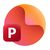

## Stacking

O **Stacking** (Stacked Generalization) é a técnica de ensemble mais sofisticada: em vez de combinar predições por votação ou média simples, treina um **meta-modelo** (*blender*) para aprender a melhor forma de combinar as saídas dos modelos base.

O processo ocorre em duas camadas:

**Camada 1 — Modelos base:** `LogisticRegression`, `RandomForestClassifier` e `SVC` são treinados com validação cruzada (`cv=5`). As predições fora da amostra (*out-of-fold*) de cada fold são usadas para treinar o meta-modelo, evitando data leakage.

**Camada 2 — Meta-modelo:** um `RandomForestClassifier` recebe como features as probabilidades preditas pelos 3 modelos base e aprende a combiná-las de forma otimizada.


> 💡 A diferença crucial entre Stacking e Voting é que o Stacking **aprende** como combinar os modelos base, enquanto o Voting usa regras fixas (maioria ou média). Isso torna o Stacking potencialmente mais poderoso, porém mais custoso computacionalmente.

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Instancia o StackingRegressor com 3 modelos base heterogêneos na camada 1:
# - LinearRegression: fronteira linear — captura padrões simples e bem separáveis
# - RandomForestRegressor: ensemble de árvores — captura relações não-lineares
# - SVC(probability=True): SVM com calibração de probabilidades (necessário para o stacking)
#
# final_estimator: meta-modelo (camada 2) que aprende a combinar as saídas dos modelos base
# Recebe como features as probabilidades preditas pelos 3 modelos base
#
# cv=5: usa validação cruzada com 5 folds para gerar as predições out-of-fold
# que treinam o meta-modelo — evita data leakage entre as duas camadas
stacking_clf = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('rf', RandomForestRegressor(random_state=42)),
        ('svr', SVR())
    ],
    final_estimator=RandomForestRegressor(random_state=43),
    cv=5  # número de folds de validação cruzada
)

# Treina simultaneamente os modelos base (via cross-val) e o meta-modelo
# O processo é mais lento que Voting/Bagging por envolver múltiplos retreinos
stacking_clf.fit(X_train, y_train)

## Exercícios

1. Qual é a profundidade aproximada de uma Árvore de Decisão treinada (sem
restrições) em um conjunto com 1 milhão de instâncias?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  A profundidade de uma árvore binária bem balanceada contendo $m$ folhas é igual a $\text{log}_2(m)$, arredondado para cima. $\text{log}_2$ é o logaritmo binário; $\text{log}_2(m) = \frac{\text{log}(m)}{\text{log}(2)}$. Uma Árvore de Decisão binária (uma que toma apenas decisões binárias, como é o caso de todas as árvores no Scikit-Learn) terminará mais ou menos bem balanceada ao final do treinamento, com uma folha por instância de treinamento se for treinada sem restrições. Assim, se o conjunto de treinamento contiver um milhão de instâncias, a Árvore de Decisão terá uma profundidade de $\text{log}_2(10^6) \approx 20$ (na verdade, um pouco mais, já que a árvore geralmente não será perfeitamente bem balanceada).
</details>

2. O coeficiente Gini de um nó geralmente é menor ou maior do que o dos seus pais? Ele é geralmente menor/maior, ou sempre menor/maior?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  A impureza de Gini de um nó é geralmente menor que a de seu pai. Isso se deve à função de custo do algoritmo de treinamento CART, que divide cada nó de forma a minimizar a soma ponderada das impurezas de Gini de seus filhos. No entanto, é possível que um nó tenha uma impureza de Gini maior que a de seu pai, desde que esse aumento seja mais do que compensado por uma diminuição na impureza do outro filho. Por exemplo, considere um nó contendo quatro instâncias da classe A e uma da classe B. Sua impureza de Gini é $1 - (\frac{1}{5})^2 - (\frac{4}{5})^2 = 0,32$. Agora, suponha que o conjunto de dados seja unidimensional e as instâncias estejam alinhadas na seguinte ordem: A, B, A, A, A. Você pode verificar que o algoritmo dividirá esse nó após a segunda instância, produzindo um nó filho com as instâncias A e B, e o outro nó filho com as instâncias A, A e A. A impureza de Gini do primeiro nó filho é $1 - (\frac{1}{2})^2 - (\frac{1}{2})^2 = 0,5$, que é maior que a do seu nó pai. Isso é compensado pelo fato de o outro nó ser puro, então sua impureza de Gini ponderada total é $\frac{2}{5} \times 0,5 \times \frac{3}{5} \times 0 = 0,2$, que é menor que a impureza de Gini do nó pai.
</details>

3. É uma boa ideia tentar diminuir seu `max_depth` se uma Árvore de Decisão estiver
se sobreajustando ao conjunto de treinamento?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Se uma árvore de decisão estiver sofrendo de sobreajuste (overfitting) no conjunto de treinamento, pode ser uma boa ideia diminuir o parâmetro `max_depth`, pois isso restringirá o modelo, regularizando-o.
</details>

4. É uma boa ideia tentar dimensionar as características de entrada se uma Árvore
de Decisão estiver se subajustando ao conjunto de treinamento?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  As árvores de decisão não se importam se os dados de treinamento são escalonados ou centralizados; essa é uma das suas grandes vantagens. Portanto, se uma árvore de decisão não se ajustar adequadamente ao conjunto de treinamento, escalonar as variáveis ​​de entrada será apenas uma perda de tempo.
</details>

5. Se treinar uma Árvore de Decisão em um conjunto de treinamento contendo 1
milhão de instâncias demora 1 hora, aproximadamente quanto tempo demorará
para treinar outra Árvore de Decisão em um conjunto de treinamento contendo
10 milhões de instâncias?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  A complexidade computacional do treinamento de uma Árvore de Decisão é O(n × m log₂(m)). Portanto, se você multiplicar o tamanho do conjunto de treinamento por 10, o tempo de treinamento será multiplicado por K = (n × 10 m × log₂(10 m)) / (n × m × log₂(m)) = 10 × log₂(10 m) / log₂(m). Se m = 10⁶, então K ≈ 11,7, portanto, você pode esperar que o tempo de treinamento seja de aproximadamente 11,7 horas.
</details>

6. Se o seu conjunto de treinamento contém 100 mil instâncias, a configuração
`presort=True` acelerará o treinamento?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Se o número de características dobrar, o tempo de treinamento também dobrará aproximadamente.
</details>

7. Treine e ajuste uma Árvore de Decisão para o conjunto de dados de luas.

a. Gere um conjunto de dados de luas utilizando `make_moons(n_samples=10000, noise=0.4)`.

In [ ]:
from sklearn.datasets import make_moons

# Adicionando random_state=42 para tornar a saída deste notebook constante:
X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)

b. Com a utilização do `train_test_split()`, divida em um conjunto de treinamento e um conjunto de testes.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons,
                                                    test_size=0.2,
                                                    random_state=42)

c. Utilize a pesquisa de grade com validação cruzada (com a ajuda da classe `GridSearchCV`) para encontrar bons valores de hiperparâmetros para um
`DecisionTreeClassifier`. Dica: tente vários valores para `max_leaf_nodes`.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)

grid_search_cv.best_estimator_

d. Treine-o no conjunto completo de treinamento utilizando estes hiperparâme-
tros e meça o desempenho do seu modelo no conjunto de teste. Você deve obter
aproximadamente 85% a 87% de acurácia.

In [ ]:
from sklearn.metrics import accuracy_score

# Por padrão, o GridSearchCV treina o melhor modelo encontrado em todo o
# conjunto de treinamento (você pode alterar isso definindo `refit=False`),
# então não precisamos fazer isso novamente. Podemos simplesmente avaliar a
# precisão do modelo:
y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

8. Cultive uma floresta.

a. Continuando o exercício anterior, gere mil subconjuntos do conjunto de treinamento, cada um contendo 100 instâncias selecionadas aleatoriamente. Dica:
você pode utilizar a classe `ShuffleSplit` do Scikit-Learn para isso.

In [ ]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances,
                  random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

b. Treine uma Árvore de Decisão em cada subconjunto utilizando os melhores valores do hiperparâmetro encontrados acima. Avalie essas mil Árvores de Decisão
no conjunto de testes. Uma vez treinadas em conjuntos menores, essas Árvores de
Decisão provavelmente terão um desempenho pior do que a primeira, alcançando
apenas 80% de acurácia.

In [ ]:
from sklearn.base import clone

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)

    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

float(np.mean(accuracy_scores))

c. Agora vem a mágica. Gere as previsões das mil Árvores de Decisão e mantenha apenas a previsão mais frequente para cada instância do conjunto de testes
(você pode utilizar a função `mode()` do SciPy para isso). Isso lhe dá previsões
dos votos majoritários sobre o conjunto de testes.

In [ ]:
from scipy.stats import mode

Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

d. Avalie estas previsões no conjunto de teste: você deve obter uma acurácia
ligeiramente maior que o seu primeiro modelo (cerca de 0,5 a 1,5% a mais).
Parabéns, você treinou um classificador de Floresta Aleatória!

In [ ]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

9. Se você treinou cinco modelos diferentes com exatamente os mesmos dados de
treinamento e todos conseguem uma precisão de 95%, existe alguma chance de
você combinar esses modelos para obter melhores resultados? Em caso afirmativo, como? Se não, por quê?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Se você treinou cinco modelos diferentes e todos eles atingiram 95% de precisão, pode tentar combiná-los em um ensemble de votação, o que geralmente proporciona resultados ainda melhores. Funciona melhor se os modelos forem muito diferentes (por exemplo, um classificador SVM, um classificador de Árvore de Decisão, um classificador de Regressão Logística e assim por diante). É ainda melhor se eles forem treinados em instâncias de treinamento diferentes (essa é a essência dos ensembles de bagging e colagem), mas, mesmo que não sejam, ainda será eficaz, desde que os modelos sejam muito diferentes.
</details>

10. Qual a diferença entre os classificadores de votação hard e soft?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Um classificador de votação rígida simplesmente conta os votos de cada classificador no conjunto e escolhe a classe que recebe mais votos. Um classificador de votação flexível calcula a probabilidade média estimada para cada classe e escolhe a classe com a maior probabilidade. Isso dá mais peso aos votos de alta confiança e geralmente apresenta melhor desempenho, mas só funciona se todos os classificadores forem capazes de estimar as probabilidades das classes (por exemplo, para os classificadores SVM no Scikit-Learn, você deve definir `probability=True`).
</details>

11. É possível acelerar o treinamento de um bagging ensemble distribuindo-o por vários
servidores? E com pasting ensembles, boosting ensembles, florestas aleatórias, ou
stacking ensembles?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  É perfeitamente possível acelerar o treinamento de um ensemble de bagging distribuindo-o por vários servidores, já que cada preditor no ensemble é independente dos demais. O mesmo vale para ensembles de pasting e Random Forests, pelo mesmo motivo. No entanto, cada preditor em um ensemble de boosting é construído com base no preditor anterior, portanto o treinamento é necessariamente sequencial, e você não ganhará nada distribuindo o treinamento por vários servidores. Em relação aos ensembles de stacking, todos os preditores em uma determinada camada são independentes entre si, então eles podem ser treinados em paralelo em vários servidores. Contudo, os preditores em uma camada só podem ser treinados depois que todos os preditores da camada anterior tiverem sido treinados.
</details>

12. Qual é o benefício da avaliação out-of-bag?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Com a avaliação fora da amostra (*out-of-bag evaluation*), cada preditor em um ensemble de bagging é avaliado usando instâncias com as quais não foi treinado (elas foram mantidas fora do conjunto de treinamento). Isso possibilita uma avaliação bastante imparcial do ensemble sem a necessidade de um conjunto de validação adicional. Assim, você tem mais instâncias disponíveis para treinamento e seu ensemble pode apresentar um desempenho ligeiramente melhor.
</details>

13. O que torna as Árvores-Extras mais aleatórias do que as Florestas Aleatórias
comuns? Como esta aleatoriedade extra pode ajudar? As Árvores-Extras são mais
lentas ou mais rápidas do que as Florestas Aleatórias regulares?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Ao construir uma árvore em uma Floresta Aleatória, apenas um subconjunto aleatório das características é considerado para a divisão em cada nó. Isso também se aplica às Árvores Extras, mas elas vão um passo além: em vez de buscar os melhores limiares possíveis, como fazem as Árvores de Decisão tradicionais, elas usam limiares aleatórios para cada característica. Essa aleatoriedade extra funciona como uma forma de regularização: se uma Floresta Aleatória sofrer sobreajuste aos dados de treinamento, as Árvores Extras podem ter um desempenho melhor. Além disso, como as Árvores Extras não buscam os melhores limiares possíveis, seu treinamento é muito mais rápido do que o das Florestas Aleatórias. No entanto, elas não são nem mais rápidas nem mais lentas do que as Florestas Aleatórias na hora de fazer previsões.
</details>

14. Se o seu ensemble AdaBoost se subajusta aos dados de treinamento, quais hiper-
parâmetros você deve ajustar e como?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Se o seu ensemble AdaBoost apresentar subajuste aos dados de treinamento, você pode tentar aumentar o número de estimadores ou reduzir os hiperparâmetros de regularização do estimador base. Você também pode tentar aumentar ligeiramente a taxa de aprendizado.
</details>

15. Se o seu ensemble Gradient Boosting se sobreajusta ao conjunto de treinamento,
você deve aumentar ou diminuir a taxa de aprendizado?

<details>
  <summary>Clique aqui para ver a resposta</summary>
  
  Se o seu ensemble de Gradient Boosting estiver sobreajustando o conjunto de treinamento, você deve tentar diminuir a taxa de aprendizado. Você também pode usar o método de parada antecipada para encontrar o número correto de preditores (provavelmente você tem preditores demais).
</details>

16. Carregue os dados MNIST e o divida em um conjunto de
treinamento, um conjunto de validação e um conjunto de teste (por exemplo, utilize
40 mil instâncias para treinamento, 10 mil para validação e 10 mil para teste). Em seguida, treine vários classificadores como um classificador Floresta Aleatória, um classificador Árvores-extra e um SVM. Em seguida, utilizando um classificador de votação soft ou hard, tente combiná-los em um ensemble que supere todos no conjunto de
validação. Uma vez tendo encontrado o ensemble, teste-o no conjunto de teste. Qual é
a melhoria de desempenho em comparação com os classificadores individuais?

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]
X_test, y_test = X_mnist[60_000:], y_mnist[60_000:]

# Nota: O `LinearSVC` possui um hiperparâmetro `dual` cujo valor padrão mudará
# de `True` para `"auto"` no Scikit-Learn 1.5. Para garantir que este notebook
# continue produzindo as mesmas saídas, estou definindo-o explicitamente como
# `True`. Consulte a [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)
# para obter mais detalhes.

random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
svm_clf = LinearSVC(max_iter=100, tol=20, dual=True, random_state=42)
mlp_clf = MLPClassifier(random_state=42)

estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]
for estimator in estimators:
    print("Treinando o ", estimator)
    estimator.fit(X_train, y_train)

scores = [estimator.score(X_valid, y_valid) for estimator in estimators]
print("Scores: ", scores)

named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
    ("svm_clf", svm_clf),
    ("mlp_clf", mlp_clf),
]

voting_clf = VotingClassifier(named_estimators)

voting_clf.fit(X_train, y_train)

print("Score: ", voting_clf.score(X_valid, y_valid))

# O VotingClassifier criou um clone de cada classificador e treinou os clones
# usando os índices das classes como rótulos, e não os nomes originais das
# classes. Portanto, para avaliar esses clones, precisamos fornecer também os
# índices das classes. Para converter as classes em índices de classe, podemos
# usar um LabelEncoder:
encoder = LabelEncoder()
y_valid_encoded = encoder.fit_transform(y_valid)

# No entanto, no caso do MNIST, é mais simples converter os nomes das classes
# em números inteiros, já que os dígitos correspondem aos IDs das classes:
y_valid_encoded = y_valid.astype(np.int64)

# Agora vamos avaliar os clones do classificador:
scores = [estimator.score(X_valid, y_valid_encoded)
 for estimator in voting_clf.estimators_]
print("Scores: ", scores)

# Vamos remover a SVM para ver se o desempenho melhora. É possível remover um
# estimador definindo-o como "drop" usando set_params() desta forma:
voting_clf.set_params(svm_clf="drop")

# Esta atualização revisou a lista de estimadores:
print(voting_clf.estimators)

# No entanto, não atualizou a lista de estimadores treinados:
print(voting_clf.estimators_)
print(voting_clf.named_estimators_)

# Assim, podemos ajustar o VotingClassifier novamente ou simplesmente remover o
# SVM da lista de estimadores treinados, tanto em estimators_ quanto em
# named_estimators_:
svm_clf_trained = voting_clf.named_estimators_.pop("svm_clf")
voting_clf.estimators_.remove(svm_clf_trained)

# Agora vamos avaliar o VotingClassifier novamente:
print("Score: ", voting_clf.score(X_valid, y_valid))

# Um pouco melhor! O SVM estava prejudicando o desempenho. Agora vamos tentar
# usar um classificador de votação flexível. Na verdade, não precisamos treinar
# o classificador novamente, podemos simplesmente definir a votação como "flexível":
voting_clf.voting = "soft"
print("Score: ", voting_clf.score(X_valid, y_valid))

# Não, neste caso, a votação rígida vence.
voting_clf.voting = "hard"
print("Score: ", voting_clf.score(X_test, y_test))
print("Scores: ", [estimator.score(X_test, y_test.astype(np.int64))
 for estimator in voting_clf.estimators_])

# O classificador de votação reduziu a taxa de erro do melhor modelo de cerca de
# 3% para 2,7%, o que significa 10% menos erros.

17. Execute os classificadores individuais do exercício anterior para fazer previsões
no conjunto de validação e crie um novo conjunto de treinamento com as previsões resultantes: cada instância de treinamento é um vetor que contém o conjunto
de previsões de todos os seus classificadores para uma imagem e o alvo é a classe
da imagem. Parabéns, você acabou de treinar um blender, e, junto com os classificadores, eles formam um stacking ensemble! Agora, avaliaremos o conjunto no
conjunto de testes. Para cada imagem no conjunto de teste, faça previsões com
todos os seus classificadores, então forneça as previsões ao blender para obter as
previsões do ensemble. Como ela se compara ao classificador de votação que você
treinou anteriormente?

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier


X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

X_train, y_train = X_mnist[:50_000], y_mnist[:50_000]
X_valid, y_valid = X_mnist[50_000:60_000], y_mnist[50_000:60_000]
X_test, y_test = X_mnist[60_000:], y_mnist[60_000:]

random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
svm_clf = LinearSVC(max_iter=100, tol=20, dual=True, random_state=42)
mlp_clf = MLPClassifier(random_state=42)

estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]
for estimator in estimators:
    print("Treinando o ", estimator)
    estimator.fit(X_train, y_train)

X_valid_predictions = np.empty((len(X_valid), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_valid_predictions[:, index] = estimator.predict(X_valid)

print(X_valid_predictions)

rnd_forest_blender = RandomForestClassifier(n_estimators=200, oob_score=True,
                                            random_state=42)
rnd_forest_blender.fit(X_valid_predictions, y_valid)

print(rnd_forest_blender.oob_score_)

X_test_predictions = np.empty((len(X_test), len(estimators)), dtype=object)

for index, estimator in enumerate(estimators):
    X_test_predictions[:, index] = estimator.predict(X_test)

y_pred = rnd_forest_blender.predict(X_test_predictions)

print(accuracy_score(y_test, y_pred))

X_train_full, y_train_full = X_mnist[:60_000], y_mnist[:60_000]

named_estimators = [
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
    ("svm_clf", svm_clf),
    ("mlp_clf", mlp_clf),
]

stack_clf = StackingClassifier(named_estimators,
                               final_estimator=rnd_forest_blender)
stack_clf.fit(X_train_full, y_train_full)

print(stack_clf.score(X_test, y_test))